# Load datasets

In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/data-crunch-round-1/sample_submission.csv
/kaggle/input/data-crunch-round-1/train.csv
/kaggle/input/data-crunch-round-1/test.csv


In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv('/kaggle/input/data-crunch-round-1/train.csv')
data.head()

,ID,Year,Month,Day,kingdom,latitude,longitude,Avg_Temperature,Avg_Feels_Like_Temperature,Temperature_Range,Feels_Like_Temperature_Range,Radiation,Rain_Amount,Rain_Duration,Wind_Speed,Wind_Direction,Evapotranspiration
0,1,1,4,1,Arcadia,24.280002,-37.229980,25.50,30.50,8.5,10.3,22.52,58.89,16,8.6,283,1.648659
1,2,1,4,1,Atlantis,22.979999,-37.329990,299.65,305.15,5.9,8.2,22.73,11.83,12,15.8,161,1.583094
2,3,1,4,1,Avalon,22.880000,-37.130006,26.30,31.50,5.2,6.4,22.73,11.83,12,15.8,161,1.593309
3,4,1,4,1,Camelot,24.180003,-36.929994,24.00,28.40,8.2,10.7,22.67,75.27,16,6.4,346,1.638997
4,5,1,4,1,Dorne,25.780002,-37.530000,28.00,32.80,5.7,10.2,22.35,4.81,8,16.7,185,1.719189


# Exploratory Data Analysis

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84960 entries, 0 to 84959
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            84960 non-null  int64  
 1   Year                          84960 non-null  int64  
 2   Month                         84960 non-null  int64  
 3   Day                           84960 non-null  int64  
 4   kingdom                       84960 non-null  object 
 5   latitude                      84960 non-null  float64
 6   longitude                     84960 non-null  float64
 7   Avg_Temperature               84960 non-null  float64
 8   Avg_Feels_Like_Temperature    84960 non-null  float64
 9   Temperature_Range             84960 non-null  float64
 10  Feels_Like_Temperature_Range  84960 non-null  float64
 11  Radiation                     84960 non-null  float64
 12  Rain_Amount                   84960 non-null  float64
 13  R

In [5]:
data.isnull().sum()

ID                              0
Year                            0
Month                           0
Day                             0
kingdom                         0
latitude                        0
longitude                       0
Avg_Temperature                 0
Avg_Feels_Like_Temperature      0
Temperature_Range               0
Feels_Like_Temperature_Range    0
Radiation                       0
Rain_Amount                     0
Rain_Duration                   0
Wind_Speed                      0
Wind_Direction                  0
Evapotranspiration              0
dtype: int64

**There are no any missing values**

In [6]:
data.duplicated().sum()

0

In [7]:
print(data.describe())

                 ID          Year         Month           Day      latitude  \
count  84960.000000  84960.000000  84960.000000  84960.000000  84960.000000   
mean   42480.500000      4.610876      6.666667     15.735876     24.003334   
std    24525.983772      2.239331      3.402793      8.802867      0.798622   
min        1.000000      1.000000      1.000000      1.000000     22.880000   
25%    21240.750000      3.000000      4.000000      8.000000     23.680003   
50%    42480.500000      5.000000      7.000000     16.000000     23.780002   
75%    63720.250000      7.000000     10.000000     23.000000     24.280002   
max    84960.000000      8.000000     12.000000     31.000000     26.580005   

          longitude  Avg_Temperature  Avg_Feels_Like_Temperature  \
count  84960.000000     84960.000000                84960.000000   
mean     -37.266665       135.600751                  139.735375   
std        0.488873       133.650417                  133.937168   
min      -37.729

In [8]:
data = data.drop(columns=['ID']) # remove id column

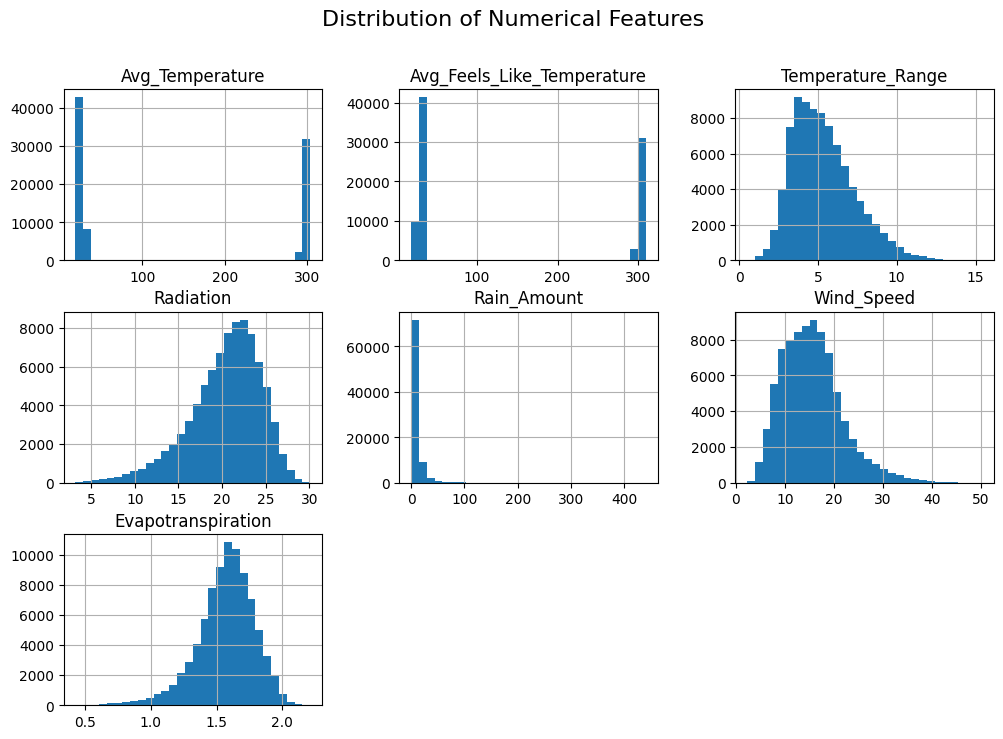

In [9]:
# Select numerical columns
numeric_cols = ["Avg_Temperature", "Avg_Feels_Like_Temperature", "Temperature_Range", 
                "Radiation", "Rain_Amount", "Wind_Speed", "Evapotranspiration"]

# Plot histograms
data[numeric_cols].hist(figsize=(12, 8), bins=30)
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.show()


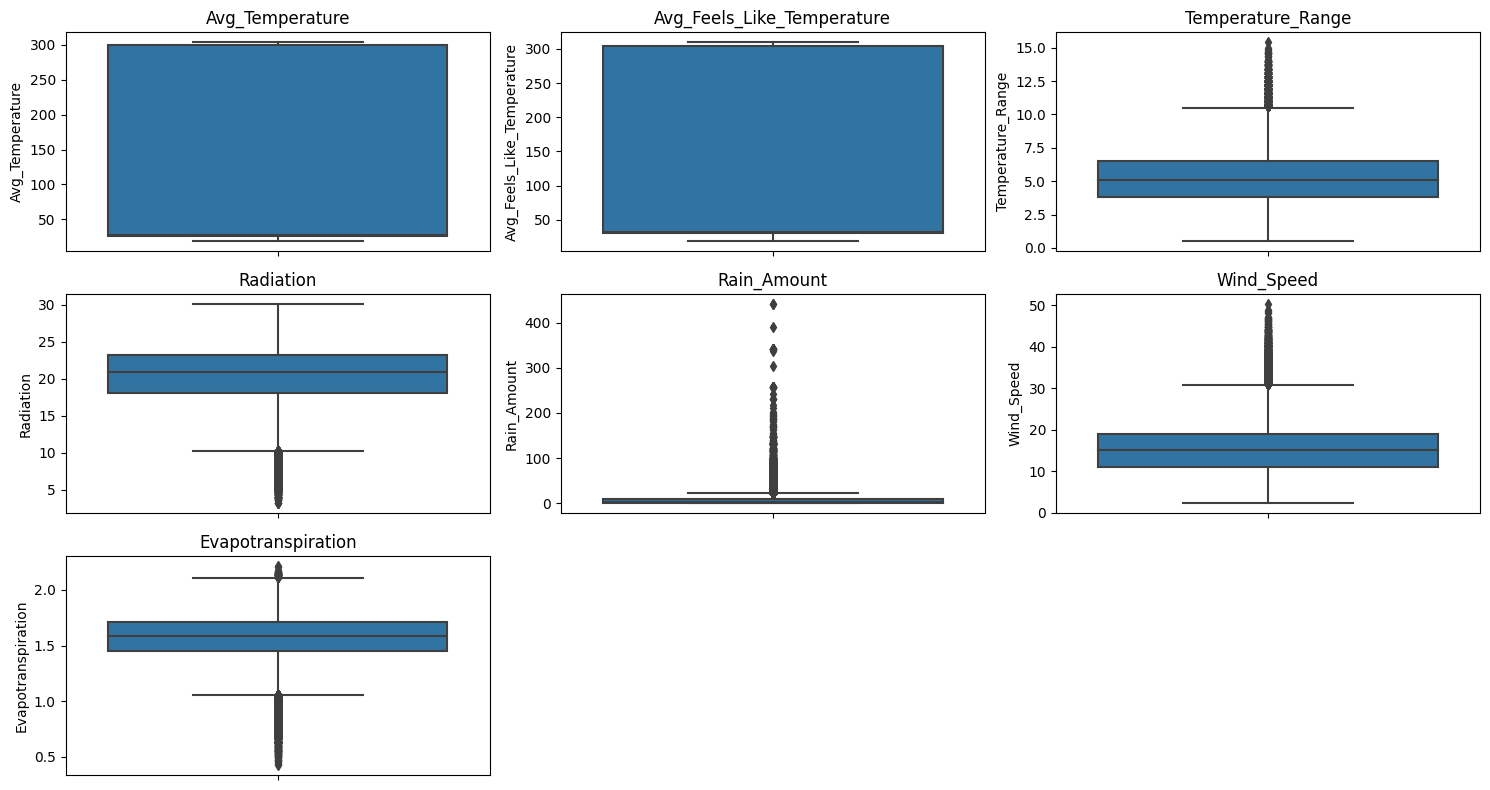

In [10]:
plt.figure(figsize=(15, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=data[col])
    plt.title(col)

plt.tight_layout()
plt.show()

# Feature Engineering

In [11]:
temp_cols = ['Avg_Temperature', 'Avg_Feels_Like_Temperature']

for col in temp_cols:
    data[col] = data[col].apply(lambda x: x - 273.15 if (x > 100) else x)

data.head()

,Year,Month,Day,kingdom,latitude,longitude,Avg_Temperature,Avg_Feels_Like_Temperature,Temperature_Range,Feels_Like_Temperature_Range,Radiation,Rain_Amount,Rain_Duration,Wind_Speed,Wind_Direction,Evapotranspiration
0,1,4,1,Arcadia,24.280002,-37.229980,25.5,30.5,8.5,10.3,22.52,58.89,16,8.6,283,1.648659
1,1,4,1,Atlantis,22.979999,-37.329990,26.5,32.0,5.9,8.2,22.73,11.83,12,15.8,161,1.583094
2,1,4,1,Avalon,22.880000,-37.130006,26.3,31.5,5.2,6.4,22.73,11.83,12,15.8,161,1.593309
3,1,4,1,Camelot,24.180003,-36.929994,24.0,28.4,8.2,10.7,22.67,75.27,16,6.4,346,1.638997
4,1,4,1,Dorne,25.780002,-37.530000,28.0,32.8,5.7,10.2,22.35,4.81,8,16.7,185,1.719189


In [12]:
# Create a new column with log-transformed rain amount
data['Rain_Amount_log'] = np.log1p(data['Rain_Amount'])

In [13]:
# Step 1: Classification based on rain amount
def classify_rain(mm):
    if mm == 0:
        return 'No Rain'
    elif mm <= 2.5:
        return 'Light'
    elif mm <= 10:
        return 'Moderate'
    else:
        return 'Heavy'

# Step 2: Apply the classifier
data['Rain_Class'] = data['Rain_Amount'].apply(classify_rain)

# Step 3: Encode as numbers (ordinal)
rain_mapping = {
    'No Rain': 0,
    'Light': 1,
    'Moderate': 2,
    'Heavy': 3
}

data['Rain_Class_Encoded'] = data['Rain_Class'].map(rain_mapping)

In [14]:
data.head()

,Year,Month,Day,kingdom,latitude,longitude,Avg_Temperature,Avg_Feels_Like_Temperature,Temperature_Range,Feels_Like_Temperature_Range,Radiation,Rain_Amount,Rain_Duration,Wind_Speed,Wind_Direction,Evapotranspiration,Rain_Amount_log,Rain_Class,Rain_Class_Encoded
0,1,4,1,Arcadia,24.280002,-37.229980,25.5,30.5,8.5,10.3,22.52,58.89,16,8.6,283,1.648659,4.092510,Heavy,3
1,1,4,1,Atlantis,22.979999,-37.329990,26.5,32.0,5.9,8.2,22.73,11.83,12,15.8,161,1.583094,2.551786,Heavy,3
2,1,4,1,Avalon,22.880000,-37.130006,26.3,31.5,5.2,6.4,22.73,11.83,12,15.8,161,1.593309,2.551786,Heavy,3
3,1,4,1,Camelot,24.180003,-36.929994,24.0,28.4,8.2,10.7,22.67,75.27,16,6.4,346,1.638997,4.334280,Heavy,3
4,1,4,1,Dorne,25.780002,-37.530000,28.0,32.8,5.7,10.2,22.35,4.81,8,16.7,185,1.719189,1.759581,Moderate,2


In [15]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data['Radiation_scaled'] = scaler.fit_transform(data[['Radiation']])

In [16]:
# Convert degrees to radians
data['Wind_Direction_rad'] = np.radians(data['Wind_Direction'])

# Calculate u and v components
data['Wind_u'] = data['Wind_Speed'] * np.cos(data['Wind_Direction_rad'])
data['Wind_v'] = data['Wind_Speed'] * np.sin(data['Wind_Direction_rad'])

# Drop intermediate if you like
data.drop(columns=['Wind_Direction_rad'], inplace=True)

In [17]:
to_scale = ['Temperature_Range', 'Evapotranspiration']
scaler = MinMaxScaler()
data[to_scale] = scaler.fit_transform(data[to_scale])

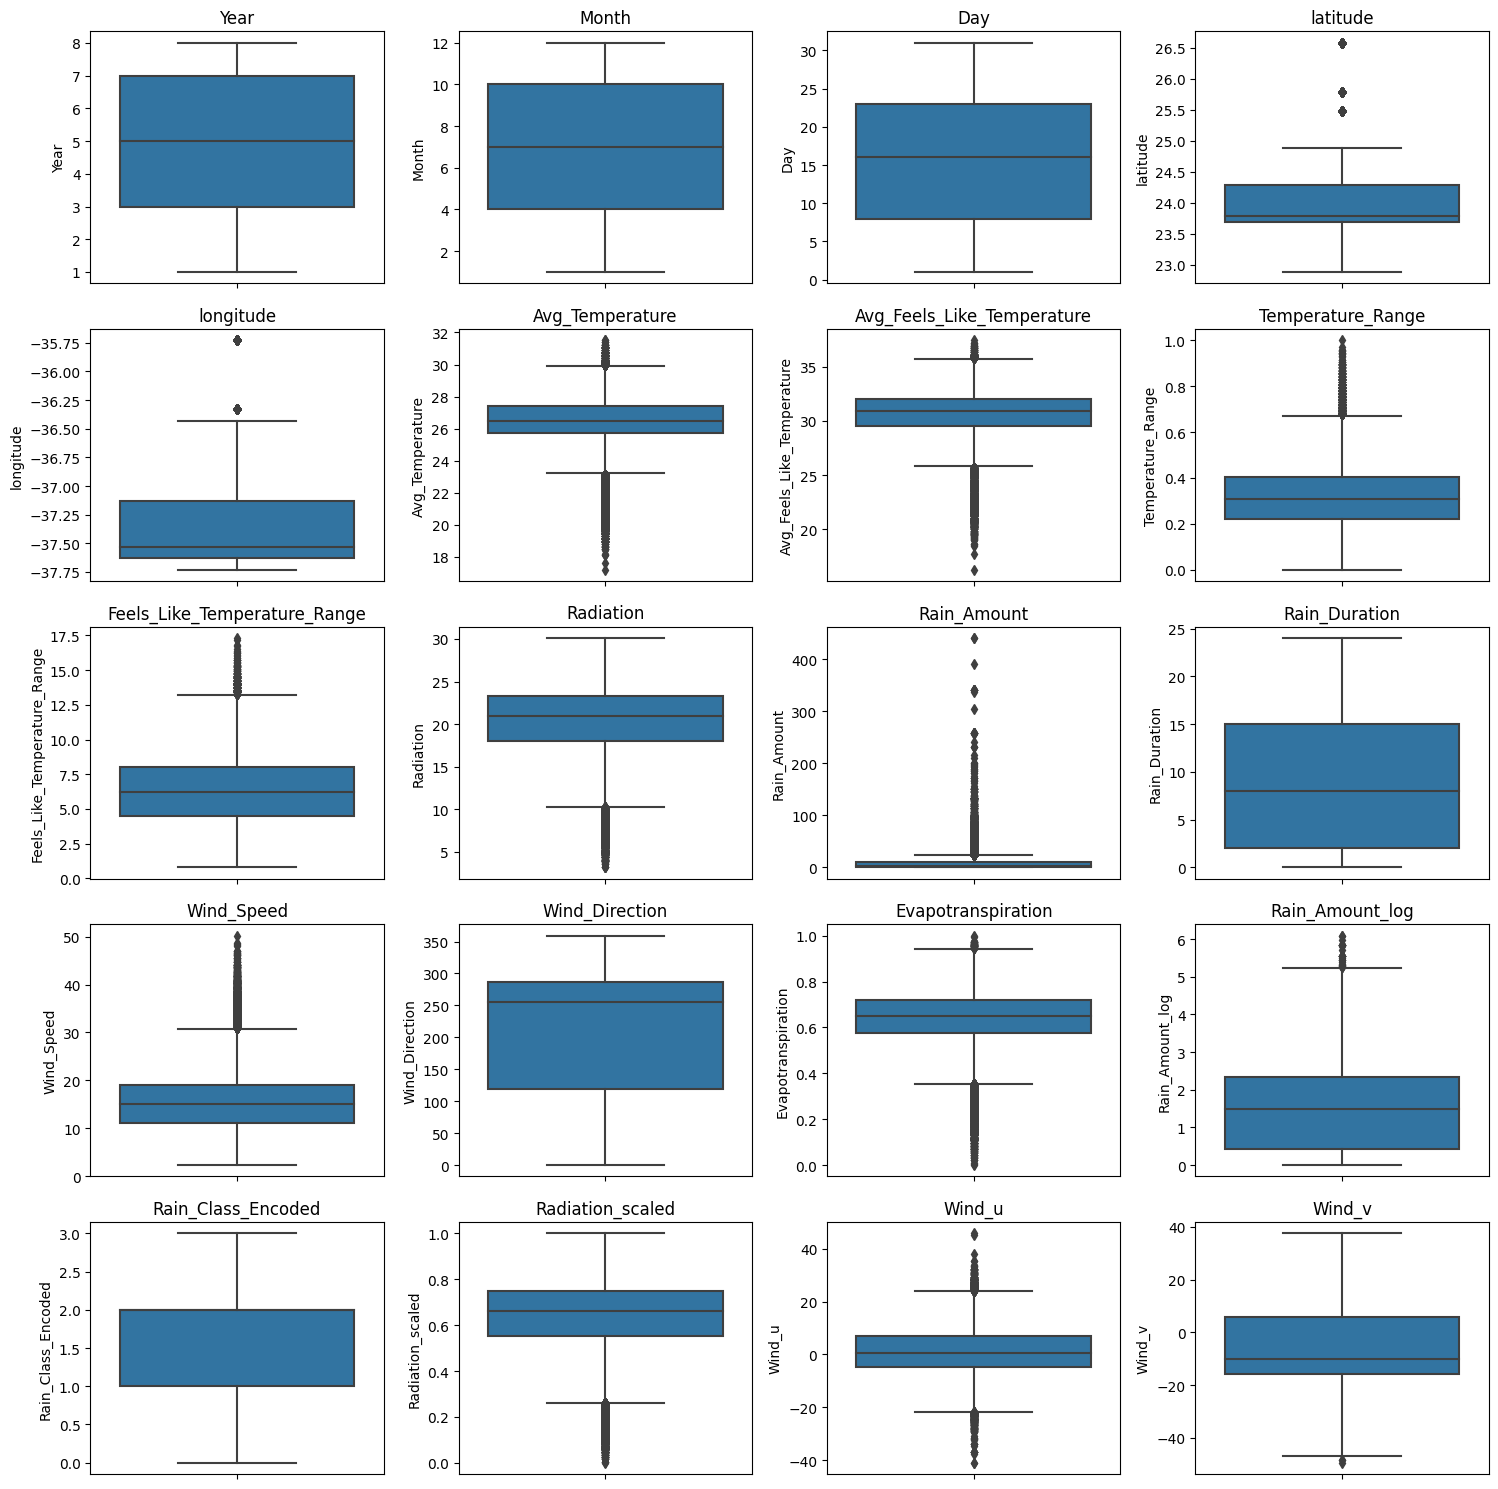

In [18]:
import math

# Detect numeric columns (both int64 and float64)
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns

# Dynamically compute rows and columns
num_cols = len(numeric_cols)
rows = math.ceil(num_cols / 4)  # 4 columns per row

plt.figure(figsize=(15, rows * 3))  # Adjust height dynamically
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, 4, i)
    sns.boxplot(y=data[col])
    plt.title(col)

plt.tight_layout()
plt.show()

**Create Time Features for Seasonality**

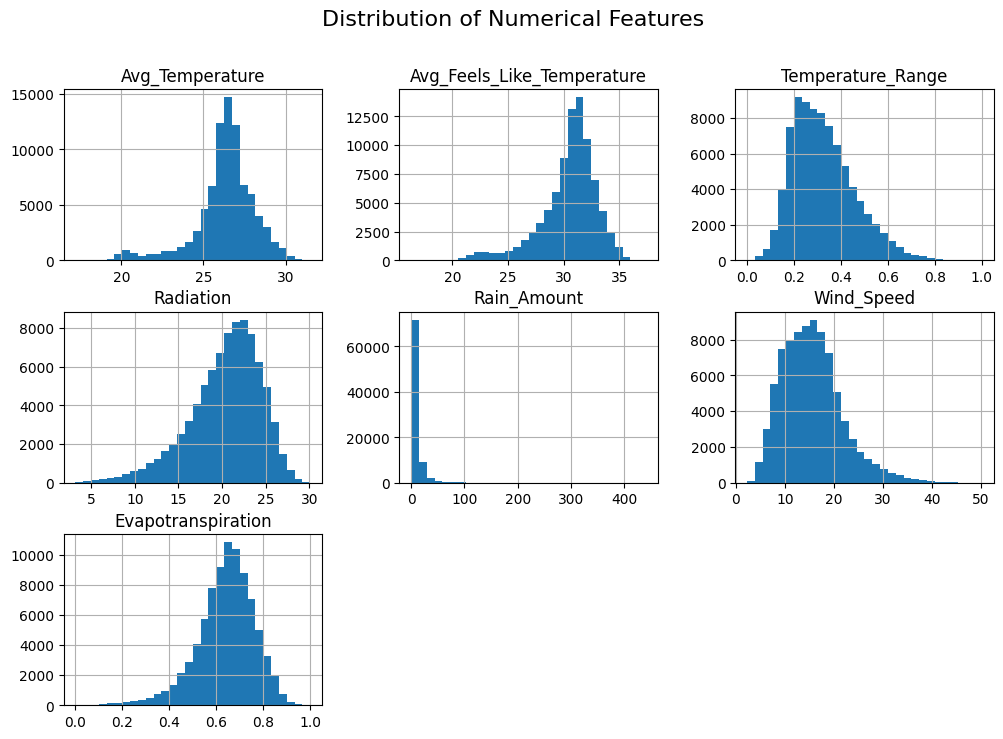

In [19]:
# Select numerical columns
numeric_cols = ["Avg_Temperature", "Avg_Feels_Like_Temperature", "Temperature_Range", 
                "Radiation", "Rain_Amount", "Wind_Speed", "Evapotranspiration"]

# Plot histograms
data[numeric_cols].hist(figsize=(12, 8), bins=30)
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.show()


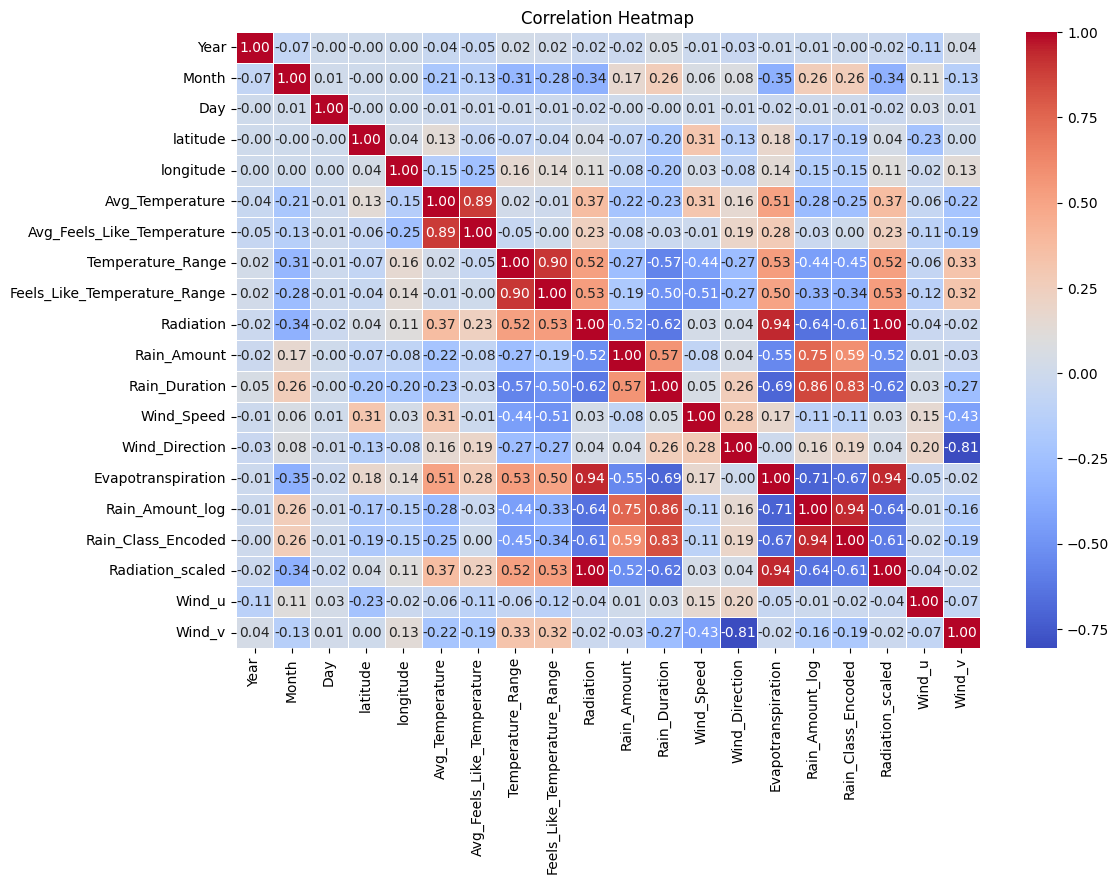

In [20]:
# Select only numeric columns
numeric_data = data.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr_matrix = numeric_data.corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

In [21]:
# Interaction terms
data['Temp_Radiation'] = data['Avg_Temperature'] * data['Radiation']
data['Wind_Combined'] = data['Wind_Speed'] * data['Evapotranspiration']

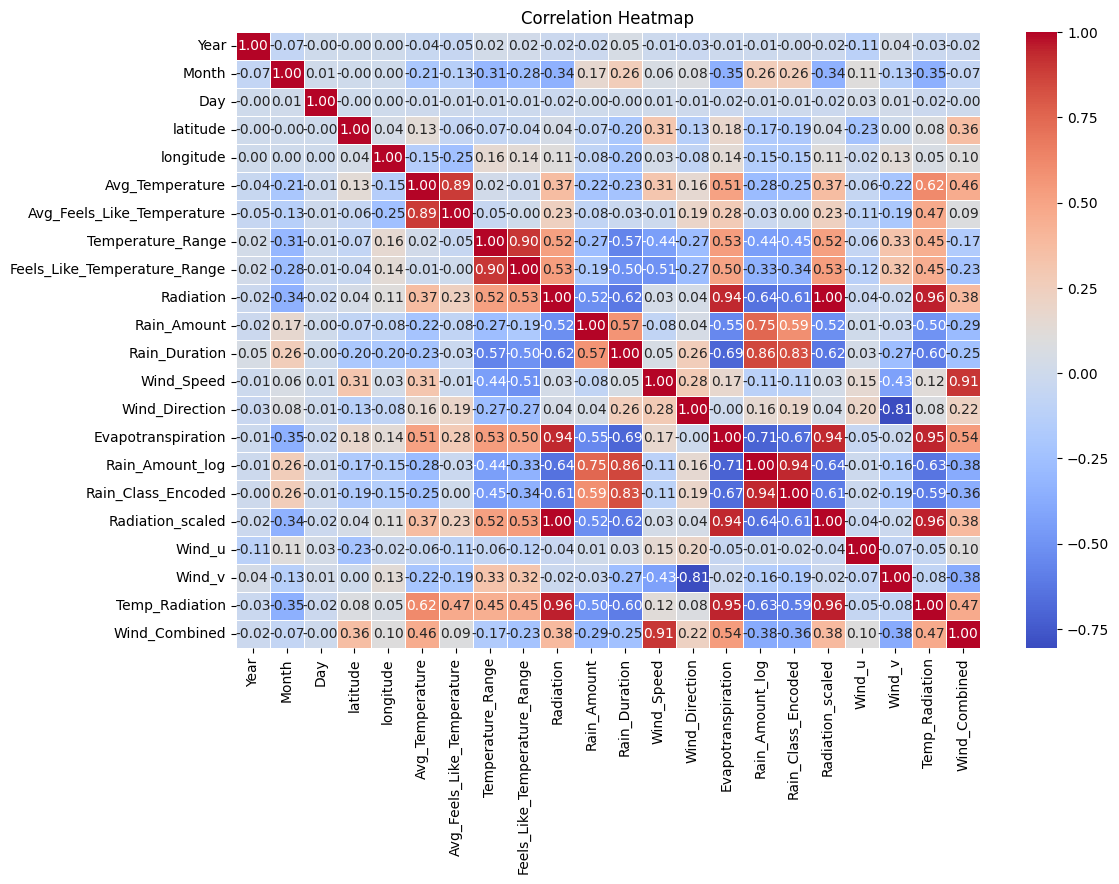

In [22]:
# Select only numeric columns
numeric_data = data.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr_matrix = numeric_data.corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

In [23]:
data.head()

,Year,Month,Day,kingdom,latitude,longitude,Avg_Temperature,Avg_Feels_Like_Temperature,Temperature_Range,Feels_Like_Temperature_Range,...,Wind_Direction,Evapotranspiration,Rain_Amount_log,Rain_Class,Rain_Class_Encoded,Radiation_scaled,Wind_u,Wind_v,Temp_Radiation,Wind_Combined
0,1,4,1,Arcadia,24.280002,-37.229980,25.5,30.5,0.536913,10.3,...,283,0.684456,4.092510,Heavy,3,0.718320,1.934579,-8.379583,574.260,5.886318
1,1,4,1,Atlantis,22.979999,-37.329990,26.5,32.0,0.362416,8.2,...,161,0.647774,2.551786,Heavy,3,0.726124,-14.939193,5.143977,602.345,10.234827
2,1,4,1,Avalon,22.880000,-37.130006,26.3,31.5,0.315436,6.4,...,161,0.653489,2.551786,Heavy,3,0.726124,-14.939193,5.143977,597.799,10.325121
3,1,4,1,Camelot,24.180003,-36.929994,24.0,28.4,0.516779,10.7,...,346,0.679050,4.334280,Heavy,3,0.723894,6.209893,-1.548300,544.080,4.345920
4,1,4,1,Dorne,25.780002,-37.530000,28.0,32.8,0.348993,10.2,...,185,0.723915,1.759581,Moderate,2,0.712003,-16.636451,-1.455501,625.800,12.089387


**One hot encoding for kingdom column** 
Best for: Random Forest, XGBoost, LightGBM, etc.

In [24]:
# Create dummies separately
kingdom_dummies = pd.get_dummies(data['kingdom'], prefix='kingdom')

# Concatenate back to original dataframe
data = pd.concat([data, kingdom_dummies], axis=1)

In [25]:
data.head()

,Year,Month,Day,kingdom,latitude,longitude,Avg_Temperature,Avg_Feels_Like_Temperature,Temperature_Range,Feels_Like_Temperature_Range,...,kingdom_Rapture,kingdom_Rivendell,kingdom_Serenity,kingdom_Shangri-La,kingdom_Solara,kingdom_Solstice,kingdom_Sunspear,kingdom_Utopia,kingdom_Valyria,kingdom_Winterfell
0,1,4,1,Arcadia,24.280002,-37.229980,25.5,30.5,0.536913,10.3,...,False,False,False,False,False,False,False,False,False,False
1,1,4,1,Atlantis,22.979999,-37.329990,26.5,32.0,0.362416,8.2,...,False,False,False,False,False,False,False,False,False,False
2,1,4,1,Avalon,22.880000,-37.130006,26.3,31.5,0.315436,6.4,...,False,False,False,False,False,False,False,False,False,False
3,1,4,1,Camelot,24.180003,-36.929994,24.0,28.4,0.516779,10.7,...,False,False,False,False,False,False,False,False,False,False
4,1,4,1,Dorne,25.780002,-37.530000,28.0,32.8,0.348993,10.2,...,False,False,False,False,False,False,False,False,False,False


In [26]:
data.columns

Index(['Year', 'Month', 'Day', 'kingdom', 'latitude', 'longitude',
       'Avg_Temperature', 'Avg_Feels_Like_Temperature', 'Temperature_Range',
       'Feels_Like_Temperature_Range', 'Radiation', 'Rain_Amount',
       'Rain_Duration', 'Wind_Speed', 'Wind_Direction', 'Evapotranspiration',
       'Rain_Amount_log', 'Rain_Class', 'Rain_Class_Encoded',
       'Radiation_scaled', 'Wind_u', 'Wind_v', 'Temp_Radiation',
       'Wind_Combined', 'kingdom_Arcadia', 'kingdom_Atlantis',
       'kingdom_Avalon', 'kingdom_Camelot', 'kingdom_Dorne', 'kingdom_Eden',
       'kingdom_El Dorado', 'kingdom_Elysium', 'kingdom_Emerald City',
       'kingdom_Helios', 'kingdom_Krypton', 'kingdom_Metropolis',
       'kingdom_Midgar', 'kingdom_Midgard', 'kingdom_Mordor',
       'kingdom_Neo-City', 'kingdom_Neo-Tokyo', 'kingdom_Nirvana',
       'kingdom_Olympus', 'kingdom_Pandora', 'kingdom_Rapture',
       'kingdom_Rivendell', 'kingdom_Serenity', 'kingdom_Shangri-La',
       'kingdom_Solara', 'kingdom_Solstice',

**LabelEncoding for Kingdom**
Deep Learning / RNNs
Best for: LSTM, GRU, or embedding layers in neural networks.

In [27]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['kingdom_encoded'] = le.fit_transform(data['kingdom'])


In [28]:
data.columns

Index(['Year', 'Month', 'Day', 'kingdom', 'latitude', 'longitude',
       'Avg_Temperature', 'Avg_Feels_Like_Temperature', 'Temperature_Range',
       'Feels_Like_Temperature_Range', 'Radiation', 'Rain_Amount',
       'Rain_Duration', 'Wind_Speed', 'Wind_Direction', 'Evapotranspiration',
       'Rain_Amount_log', 'Rain_Class', 'Rain_Class_Encoded',
       'Radiation_scaled', 'Wind_u', 'Wind_v', 'Temp_Radiation',
       'Wind_Combined', 'kingdom_Arcadia', 'kingdom_Atlantis',
       'kingdom_Avalon', 'kingdom_Camelot', 'kingdom_Dorne', 'kingdom_Eden',
       'kingdom_El Dorado', 'kingdom_Elysium', 'kingdom_Emerald City',
       'kingdom_Helios', 'kingdom_Krypton', 'kingdom_Metropolis',
       'kingdom_Midgar', 'kingdom_Midgard', 'kingdom_Mordor',
       'kingdom_Neo-City', 'kingdom_Neo-Tokyo', 'kingdom_Nirvana',
       'kingdom_Olympus', 'kingdom_Pandora', 'kingdom_Rapture',
       'kingdom_Rivendell', 'kingdom_Serenity', 'kingdom_Shangri-La',
       'kingdom_Solara', 'kingdom_Solstice',

In [29]:
data.head()

,Year,Month,Day,kingdom,latitude,longitude,Avg_Temperature,Avg_Feels_Like_Temperature,Temperature_Range,Feels_Like_Temperature_Range,...,kingdom_Rivendell,kingdom_Serenity,kingdom_Shangri-La,kingdom_Solara,kingdom_Solstice,kingdom_Sunspear,kingdom_Utopia,kingdom_Valyria,kingdom_Winterfell,kingdom_encoded
0,1,4,1,Arcadia,24.280002,-37.229980,25.5,30.5,0.536913,10.3,...,False,False,False,False,False,False,False,False,False,0
1,1,4,1,Atlantis,22.979999,-37.329990,26.5,32.0,0.362416,8.2,...,False,False,False,False,False,False,False,False,False,1
2,1,4,1,Avalon,22.880000,-37.130006,26.3,31.5,0.315436,6.4,...,False,False,False,False,False,False,False,False,False,2
3,1,4,1,Camelot,24.180003,-36.929994,24.0,28.4,0.516779,10.7,...,False,False,False,False,False,False,False,False,False,3
4,1,4,1,Dorne,25.780002,-37.530000,28.0,32.8,0.348993,10.2,...,False,False,False,False,False,False,False,False,False,4
